# Model-Based vs Model-Free (RL): Regret Comparison

**Ergodic Market Making Setting**

Regret definition (slides p.45):
$$\mathcal{R}^\Psi(T) = \gamma(\kappa^*) \cdot T - \mathbb{E}_q\left[\int_0^T f(\cdot, \psi^{\kappa_t}; \kappa^*) \,\mathrm{d}t \right]$$

where $\gamma(\kappa^*)$ is the ergodic constant under the true parameter.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from simulator import MarketSimulator
from HJB import ErgodicCP
from agent_model_based import ModelBasedAgent
from agent_model_free import ModelFreeAgent

## 1. Shared Parameters

In [8]:
# Environment parameters
kappa_true = 10.0
lambda_buy = 0.4
lambda_sell = 0.4
q_upper, q_lower = 30, -30
phi = 1e-6
sigma = 0.01

T = 2000
dt = 1.0
n_steps = int(T / dt)

# Model-based agent params
kappa_init_range = (5, 50)
K_upper = 100
delta0 = 1e-8

# Model-free agent params
delta_min = 0.01
delta_max = 0.5
n_delta = 15
mf_lr = 0.005
mf_avg_lr = 0.001
mf_temperature = 0.5

# Monte Carlo
n_MC = 50

## 2. Compute True Ergodic Constant (Benchmark)

<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
C:\Users\xiang\AppData\Local\Temp\ipykernel_37548\1650643035.py:21: SyntaxWarning: invalid escape sequence '\$'
  plt.ylabel('$\\delta^{\\pm}(\$)$')


True ergodic constant gamma(kappa*) = 0.029309
True optimal control (q=0): delta_sell=0.1004, delta_buy=0.1004
1/kappa = 0.1000


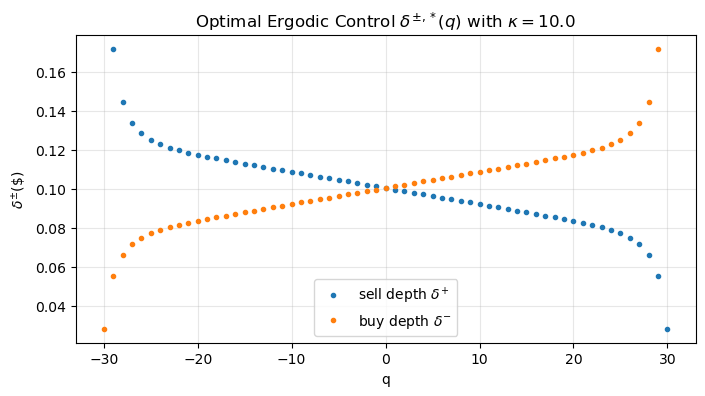

In [9]:
true_ecp = ErgodicCP(
    lambda_buy=lambda_buy, lambda_sell=lambda_sell,
    q_upper=q_upper, q_lower=q_lower,
    phi=phi, kappa=kappa_true,
)
gamma_star = true_ecp.EConst

print(f"True ergodic constant gamma(kappa*) = {gamma_star:.6f}")
print(f"True optimal control (q=0): delta_sell={true_ecp.get_control_for_q(0)[0]:.4f}, "
      f"delta_buy={true_ecp.get_control_for_q(0)[1]:.4f}")
print(f"1/kappa = {1/kappa_true:.4f}")

# Plot the optimal ergodic control
true_ecp.plot_EControl = None  # use manual plot
delta_sell_arr, delta_buy_arr = true_ecp.EControl
inventory = np.arange(q_lower, q_upper + 1, 1)
plt.figure(figsize=(8, 4))
plt.plot(inventory[1:], delta_sell_arr, 'o', label='sell depth $\\delta^{+}$', markersize=3)
plt.plot(inventory[:-1], delta_buy_arr, 'o', label='buy depth $\\delta^{-}$', markersize=3)
plt.xlabel('q')
plt.ylabel('$\\delta^{\\pm}(\$)$')
plt.title(f'Optimal Ergodic Control $\\delta^{{\\pm,*}}(q)$ with $\\kappa={kappa_true}$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Helper Functions

In [10]:
def run_single(seed, agent_type='model_based', mf_params=None):
    """
    Run a single trajectory.
    
    Args:
        seed: random seed for the environment
        agent_type: 'model_based' or 'model_free'
        mf_params: dict of model-free hyperparameters (optional override)
    
    Returns:
        ts, objectives, kappa_history (or None)
    """
    env = MarketSimulator(
        sigma=sigma, kappa_true=kappa_true,
        lambda_buy=lambda_buy, lambda_sell=lambda_sell,
        dt=dt, S0=10.0,
        q_upper=q_upper, q_lower=q_lower,
        phi=phi, seed=seed,
    )
    env.reset()

    if agent_type == 'model_based':
        kappa_init = np.random.uniform(*kappa_init_range)
        agent = ModelBasedAgent(
            lambda_buy=lambda_buy, lambda_sell=lambda_sell,
            q_upper=q_upper, q_lower=q_lower,
            phi=phi, kappa_init=kappa_init,
            K_lower=1.0, K_upper=K_upper, delta0=delta0,
            update_freq=5,
        )
    elif agent_type == 'model_free':
        p = mf_params or {}
        agent = ModelFreeAgent(
            q_lower=q_lower, q_upper=q_upper,
            delta_min=p.get('delta_min', delta_min),
            delta_max=p.get('delta_max', delta_max),
            n_delta=p.get('n_delta', n_delta),
            lr=p.get('lr', mf_lr),
            avg_reward_lr=p.get('avg_reward_lr', mf_avg_lr),
            temperature=p.get('temperature', mf_temperature),
            seed=seed + 10000,
        )
    else:
        raise ValueError(f"Unknown agent type: {agent_type}")

    objectives = np.zeros(n_steps + 1)
    ts = np.linspace(0, T, n_steps + 1)

    for step in range(n_steps):
        q = env.Q
        if agent_type == 'model_based':
            delta_sell, delta_buy = agent.get_action(q)
            state, reward, info = env.step(delta_sell, delta_buy)
            agent.update(delta_sell, delta_buy, info)
        else:
            delta_sell, delta_buy, action_idx = agent.get_action(q)
            state, reward, info = env.step(delta_sell, delta_buy)
            agent.update(q, action_idx, reward)
        objectives[step + 1] = env.objective()

    kappa_hist = agent.kappa_history if agent_type == 'model_based' else None
    return ts, objectives, kappa_hist


def run_MC(n_MC, agent_type='model_based', mf_params=None):
    """Run Monte Carlo simulations and return regret array."""
    MC_regret = []
    MC_extra = []  # kappa history for MB, or None for MF
    for mc in range(n_MC):
        if (mc + 1) % 10 == 0 or mc == 0:
            print(f"  {agent_type} MC run {mc+1}/{n_MC}")
        seed = 1000 + mc
        ts, obj, extra = run_single(seed, agent_type, mf_params)
        regret = gamma_star * ts - obj
        MC_regret.append(regret)
        MC_extra.append(extra)
    return ts, np.array(MC_regret), MC_extra


# Curve fitting helpers
def log_square_model(x, c, m):
    return c * (np.log(x)**2) + m

def log_model(x, c, m):
    return c * np.log(x) + m

def sqrt_model(x, c, m):
    return c * np.sqrt(x) + m

def calculate_r2(data, fit_data):
    ss_res = np.sum((data - fit_data)**2)
    ss_tot = np.sum((data - np.mean(data))**2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0

## 4. Monte Carlo Simulation

In [11]:
print("Running Model-Based...")
ts, MC_regret_mb, MC_kappa_list = run_MC(n_MC, 'model_based')

print("\nRunning Model-Free...")
ts, MC_regret_mf, _ = run_MC(n_MC, 'model_free')

print("Done!")

Running Model-Based...
  model_based MC run 1/50
  model_based MC run 10/50
  model_based MC run 20/50
  model_based MC run 30/50
  model_based MC run 40/50
  model_based MC run 50/50

Running Model-Free...
  model_free MC run 1/50
  model_free MC run 10/50
  model_free MC run 20/50
  model_free MC run 30/50
  model_free MC run 40/50
  model_free MC run 50/50
Done!


## 5. Regret Comparison Plots

In [12]:
# Statistics
mean_regret_mb = np.mean(MC_regret_mb, axis=0)
ci_regret_mb = 1.96 * np.std(MC_regret_mb, axis=0) / np.sqrt(n_MC)

mean_regret_mf = np.mean(MC_regret_mf, axis=0)
ci_regret_mf = 1.96 * np.std(MC_regret_mf, axis=0) / np.sqrt(n_MC)

# Curve fitting
start = max(10, int(0.1 * n_steps))
x_fit = ts[start:]

params_mb_log2, _ = curve_fit(log_square_model, x_fit, mean_regret_mb[start:])
params_mb_log, _  = curve_fit(log_model, x_fit, mean_regret_mb[start:])

params_mf_log2, _ = curve_fit(log_square_model, x_fit, mean_regret_mf[start:])
params_mf_log, _  = curve_fit(log_model, x_fit, mean_regret_mf[start:])
params_mf_sqrt, _ = curve_fit(sqrt_model, x_fit, mean_regret_mf[start:])

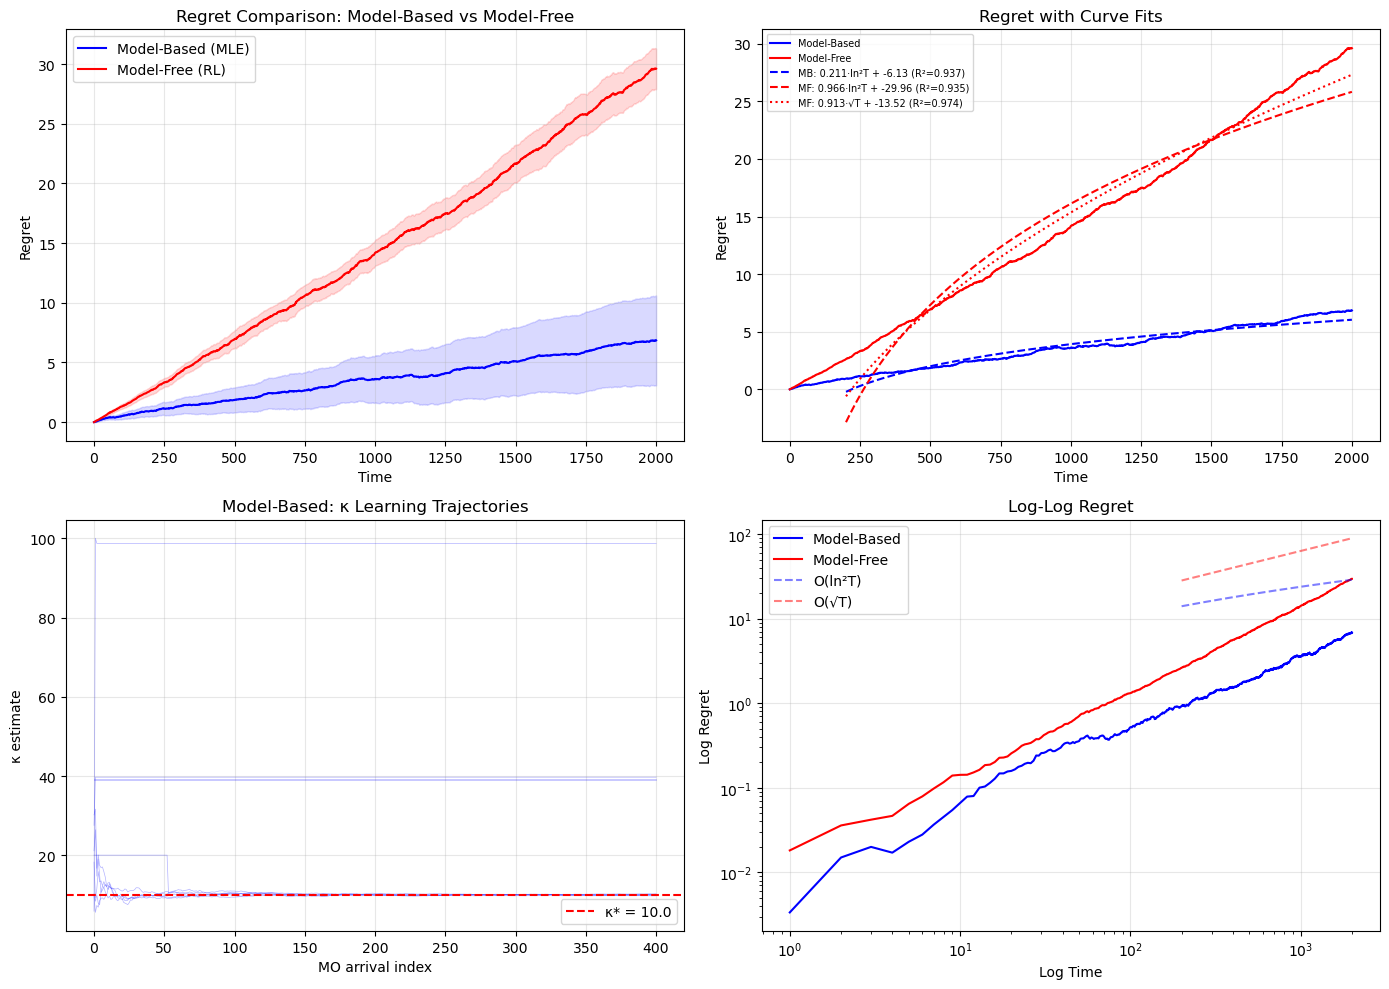

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Regret comparison with CI ---
ax = axes[0, 0]
ax.plot(ts, mean_regret_mb, 'b-', label='Model-Based (MLE)', linewidth=1.5)
ax.fill_between(ts, mean_regret_mb - ci_regret_mb, mean_regret_mb + ci_regret_mb,
                color='b', alpha=0.15)
ax.plot(ts, mean_regret_mf, 'r-', label='Model-Free (RL)', linewidth=1.5)
ax.fill_between(ts, mean_regret_mf - ci_regret_mf, mean_regret_mf + ci_regret_mf,
                color='r', alpha=0.15)
ax.set_xlabel('Time')
ax.set_ylabel('Regret')
ax.set_title('Regret Comparison: Model-Based vs Model-Free')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Regret with curve fits ---
ax = axes[0, 1]
ax.plot(ts, mean_regret_mb, 'b-', label='Model-Based', linewidth=1.5)
ax.plot(ts, mean_regret_mf, 'r-', label='Model-Free', linewidth=1.5)

y_fit = log_square_model(x_fit, *params_mb_log2)
r2 = calculate_r2(mean_regret_mb[start:], y_fit)
ax.plot(x_fit, y_fit, 'b--',
        label=f'MB: {params_mb_log2[0]:.3f}·ln²T + {params_mb_log2[1]:.2f} (R²={r2:.3f})')

y_fit = log_square_model(x_fit, *params_mf_log2)
r2 = calculate_r2(mean_regret_mf[start:], y_fit)
ax.plot(x_fit, y_fit, 'r--',
        label=f'MF: {params_mf_log2[0]:.3f}·ln²T + {params_mf_log2[1]:.2f} (R²={r2:.3f})')

y_fit = sqrt_model(x_fit, *params_mf_sqrt)
r2 = calculate_r2(mean_regret_mf[start:], y_fit)
ax.plot(x_fit, y_fit, 'r:',
        label=f'MF: {params_mf_sqrt[0]:.3f}·√T + {params_mf_sqrt[1]:.2f} (R²={r2:.3f})')

ax.set_xlabel('Time')
ax.set_ylabel('Regret')
ax.set_title('Regret with Curve Fits')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Plot 3: Kappa learning ---
ax = axes[1, 0]
for i in range(min(10, n_MC)):
    k = MC_kappa_list[i]
    if k is not None:
        ax.plot(range(len(k)), k, alpha=0.3, color='blue', linewidth=0.5)
ax.axhline(y=kappa_true, color='red', linestyle='--', label=f'κ* = {kappa_true}')
ax.set_xlabel('MO arrival index')
ax.set_ylabel('κ estimate')
ax.set_title('Model-Based: κ Learning Trajectories')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 4: Log-log regret ---
ax = axes[1, 1]
pos_mb = mean_regret_mb > 0
pos_mf = mean_regret_mf > 0
if np.any(pos_mb):
    ax.loglog(ts[pos_mb], mean_regret_mb[pos_mb], 'b-', label='Model-Based')
if np.any(pos_mf):
    ax.loglog(ts[pos_mf], mean_regret_mf[pos_mf], 'r-', label='Model-Free')
t_ref = ts[start:]
ax.loglog(t_ref, 0.5 * np.log(t_ref)**2, 'b--', alpha=0.5, label='O(ln²T)')
ax.loglog(t_ref, 2 * np.sqrt(t_ref), 'r--', alpha=0.5, label='O(√T)')
ax.set_xlabel('Log Time')
ax.set_ylabel('Log Regret')
ax.set_title('Log-Log Regret')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regret_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [14]:
# Print summary
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"True kappa: {kappa_true}")
print(f"Ergodic constant gamma(kappa*): {gamma_star:.6f}")
print(f"Simulation: T={T}, dt={dt}, MC={n_MC}")
print(f"\nFinal regret at T={T}:")
print(f"  Model-Based:  {mean_regret_mb[-1]:.4f} ± {ci_regret_mb[-1]:.4f}")
print(f"  Model-Free:   {mean_regret_mf[-1]:.4f} ± {ci_regret_mf[-1]:.4f}")
print(f"\nCurve fits:")
print(f"  MB: {params_mb_log2[0]:.4f}·ln²T + {params_mb_log2[1]:.4f}")
print(f"  MF (ln²T): {params_mf_log2[0]:.4f}·ln²T + {params_mf_log2[1]:.4f}")
print(f"  MF (√T):   {params_mf_sqrt[0]:.4f}·√T + {params_mf_sqrt[1]:.4f}")

SUMMARY
True kappa: 10.0
Ergodic constant gamma(kappa*): 0.029309
Simulation: T=2000, dt=1.0, MC=50

Final regret at T=2000:
  Model-Based:  6.8413 ± 3.7646
  Model-Free:   29.6106 ± 1.6948

Curve fits:
  MB: 0.2106·ln²T + -6.1267
  MF (ln²T): 0.9657·ln²T + -29.9622
  MF (√T):   0.9130·√T + -13.5185


## 6. Sensitivity Analysis: Model-Free Learning Rate

Test how different learning rates affect the model-free agent's regret.

In [15]:
lr_values = [0.001,  0.1, 1, 2, 5]
n_MC_sens = 100  # fewer MC runs for sensitivity test

sensitivity_results = {}

for lr_val in lr_values:
    print(f"\nTesting lr = {lr_val}...")
    mf_params = {'lr': lr_val}
    ts_s, MC_regret_s, _ = run_MC(n_MC_sens, 'model_free', mf_params)
    sensitivity_results[lr_val] = {
        'mean': np.mean(MC_regret_s, axis=0),
        'ci': 1.96 * np.std(MC_regret_s, axis=0) / np.sqrt(n_MC_sens),
    }

print("\nDone!")


Testing lr = 0.001...
  model_free MC run 1/100
  model_free MC run 10/100
  model_free MC run 20/100
  model_free MC run 30/100
  model_free MC run 40/100
  model_free MC run 50/100
  model_free MC run 60/100
  model_free MC run 70/100
  model_free MC run 80/100
  model_free MC run 90/100
  model_free MC run 100/100

Testing lr = 0.1...
  model_free MC run 1/100
  model_free MC run 10/100
  model_free MC run 20/100
  model_free MC run 30/100
  model_free MC run 40/100
  model_free MC run 50/100
  model_free MC run 60/100
  model_free MC run 70/100
  model_free MC run 80/100
  model_free MC run 90/100
  model_free MC run 100/100

Testing lr = 1...
  model_free MC run 1/100
  model_free MC run 10/100
  model_free MC run 20/100
  model_free MC run 30/100
  model_free MC run 40/100
  model_free MC run 50/100
  model_free MC run 60/100
  model_free MC run 70/100
  model_free MC run 80/100
  model_free MC run 90/100
  model_free MC run 100/100

Testing lr = 2...
  model_free MC run 1/100
 

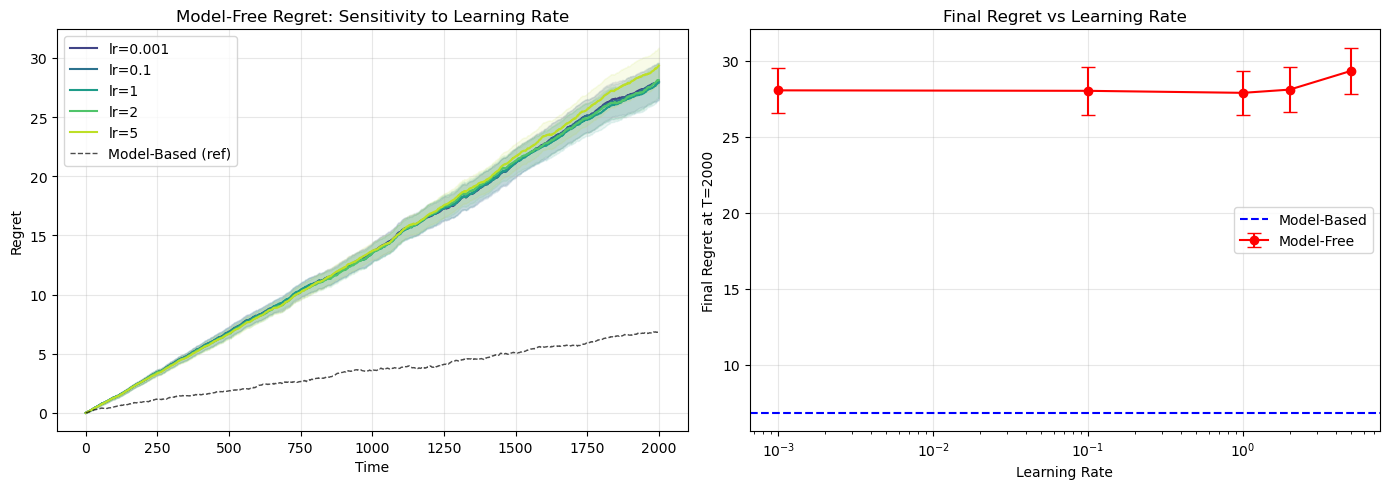


Final regret at T=2000 for different learning rates:
  lr=0.001 : regret = 28.0557 ± 1.4999
  lr=0.1   : regret = 28.0245 ± 1.5679
  lr=1     : regret = 27.8924 ± 1.4526
  lr=2     : regret = 28.1042 ± 1.4730
  lr=5     : regret = 29.3423 ± 1.5258
  Model-Based:  regret = 6.8413 ± 3.7646


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Regret curves for different lr ---
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(lr_values)))
for i, lr_val in enumerate(lr_values):
    res = sensitivity_results[lr_val]
    ax.plot(ts, res['mean'], color=colors[i], label=f'lr={lr_val}', linewidth=1.5)
    ax.fill_between(ts, res['mean'] - res['ci'], res['mean'] + res['ci'],
                    color=colors[i], alpha=0.1)

# Add model-based as reference
ax.plot(ts, mean_regret_mb, 'k--', label='Model-Based (ref)', linewidth=1, alpha=0.7)

ax.set_xlabel('Time')
ax.set_ylabel('Regret')
ax.set_title('Model-Free Regret: Sensitivity to Learning Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: Final regret vs lr ---
ax = axes[1]
final_regrets = [sensitivity_results[lr]['mean'][-1] for lr in lr_values]
final_cis = [sensitivity_results[lr]['ci'][-1] for lr in lr_values]
ax.errorbar(lr_values, final_regrets, yerr=final_cis, fmt='o-', color='red',
            capsize=5, label='Model-Free')
ax.axhline(y=mean_regret_mb[-1], color='blue', linestyle='--', label='Model-Based')
ax.set_xscale('log')
ax.set_xlabel('Learning Rate')
ax.set_ylabel(f'Final Regret at T={T}')
ax.set_title('Final Regret vs Learning Rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sensitivity_lr.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Print summary
print("\nFinal regret at T={} for different learning rates:".format(T))
for lr_val in lr_values:
    r = sensitivity_results[lr_val]
    print(f"  lr={lr_val:<6}: regret = {r['mean'][-1]:.4f} ± {r['ci'][-1]:.4f}")
print(f"  Model-Based:  regret = {mean_regret_mb[-1]:.4f} ± {ci_regret_mb[-1]:.4f}")

## 7. Sensitivity Analysis: Model-Free Temperature

Test how softmax temperature (exploration level) affects regret.

In [17]:
temp_values = [0.1, 0.3, 0.5, 1.0, 2.0]

temp_results = {}

for temp_val in temp_values:
    print(f"\nTesting temperature = {temp_val}...")
    mf_params = {'temperature': temp_val}
    ts_s, MC_regret_s, _ = run_MC(n_MC_sens, 'model_free', mf_params)
    temp_results[temp_val] = {
        'mean': np.mean(MC_regret_s, axis=0),
        'ci': 1.96 * np.std(MC_regret_s, axis=0) / np.sqrt(n_MC_sens),
    }

print("\nDone!")


Testing temperature = 0.1...
  model_free MC run 1/100
  model_free MC run 10/100
  model_free MC run 20/100
  model_free MC run 30/100
  model_free MC run 40/100
  model_free MC run 50/100
  model_free MC run 60/100
  model_free MC run 70/100
  model_free MC run 80/100
  model_free MC run 90/100
  model_free MC run 100/100

Testing temperature = 0.3...
  model_free MC run 1/100
  model_free MC run 10/100
  model_free MC run 20/100
  model_free MC run 30/100
  model_free MC run 40/100
  model_free MC run 50/100
  model_free MC run 60/100
  model_free MC run 70/100
  model_free MC run 80/100
  model_free MC run 90/100
  model_free MC run 100/100

Testing temperature = 0.5...
  model_free MC run 1/100
  model_free MC run 10/100
  model_free MC run 20/100
  model_free MC run 30/100
  model_free MC run 40/100
  model_free MC run 50/100
  model_free MC run 60/100
  model_free MC run 70/100
  model_free MC run 80/100
  model_free MC run 90/100
  model_free MC run 100/100

Testing temperatur

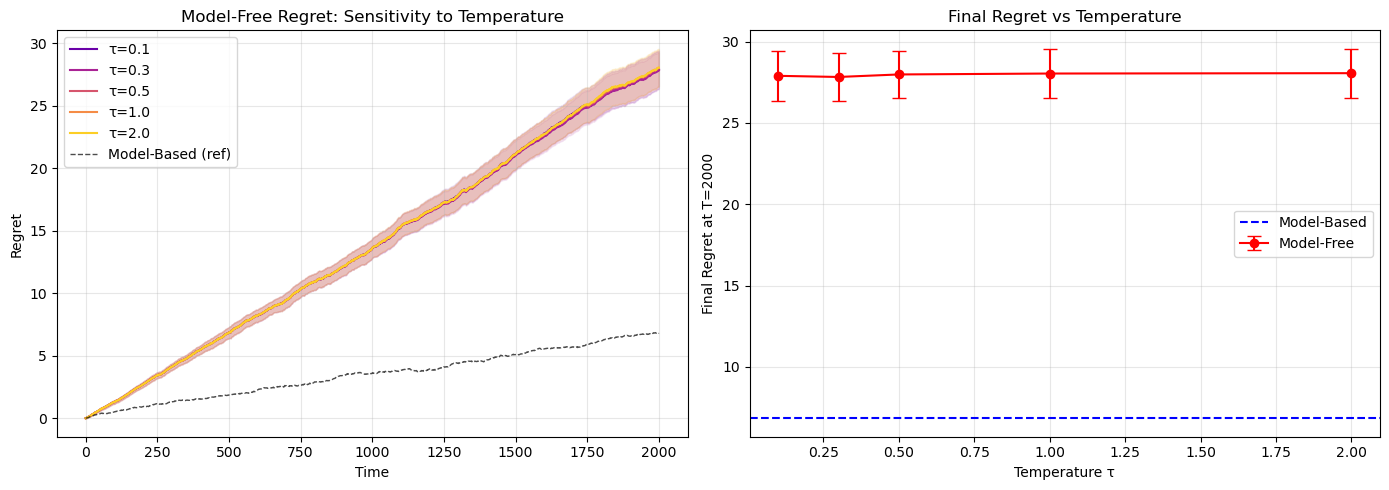


Final regret at T=2000 for different temperatures:
  τ=0.1   : regret = 27.8976 ± 1.5183
  τ=0.3   : regret = 27.8278 ± 1.4632
  τ=0.5   : regret = 27.9825 ± 1.4329
  τ=1.0   : regret = 28.0388 ± 1.4954
  τ=2.0   : regret = 28.0609 ± 1.4985
  Model-Based:  regret = 6.8413 ± 3.7646


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Regret curves ---
ax = axes[0]
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(temp_values)))
for i, temp_val in enumerate(temp_values):
    res = temp_results[temp_val]
    ax.plot(ts, res['mean'], color=colors[i], label=f'τ={temp_val}', linewidth=1.5)
    ax.fill_between(ts, res['mean'] - res['ci'], res['mean'] + res['ci'],
                    color=colors[i], alpha=0.1)

ax.plot(ts, mean_regret_mb, 'k--', label='Model-Based (ref)', linewidth=1, alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Regret')
ax.set_title('Model-Free Regret: Sensitivity to Temperature')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: Final regret vs temperature ---
ax = axes[1]
final_regrets = [temp_results[t]['mean'][-1] for t in temp_values]
final_cis = [temp_results[t]['ci'][-1] for t in temp_values]
ax.errorbar(temp_values, final_regrets, yerr=final_cis, fmt='o-', color='red',
            capsize=5, label='Model-Free')
ax.axhline(y=mean_regret_mb[-1], color='blue', linestyle='--', label='Model-Based')
ax.set_xlabel('Temperature τ')
ax.set_ylabel(f'Final Regret at T={T}')
ax.set_title('Final Regret vs Temperature')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sensitivity_temperature.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("\nFinal regret at T={} for different temperatures:".format(T))
for temp_val in temp_values:
    r = temp_results[temp_val]
    print(f"  τ={temp_val:<6}: regret = {r['mean'][-1]:.4f} ± {r['ci'][-1]:.4f}")
print(f"  Model-Based:  regret = {mean_regret_mb[-1]:.4f} ± {ci_regret_mb[-1]:.4f}")